# 畳み込みニューラルネットワーク（CNN）Sequential API編

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras/blob/main/2_Keras_CNN_Sequential-API.ipynb)

`1_Keras_MLP.ipynb`と同じFashion-MNISTデータセットを使い、`Conv2D`（畳み込み層）を使ったCNNをSequential APIで組み立てます。「画像の位置関係を無視するMLP」と「位置関係を利用するCNN」の違いを比較できるようにしています。

## 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: `1_Keras_MLP.ipynb`を読んだ方、またはKerasの`Sequential` APIの基本（層を積む・`compile`・`fit`）を知っている方
- **前提知識**: MLP編で説明した正規化・one-hotエンコーディング・エポック・バッチサイズなどの用語は既知として進める
- **動作環境**: Python 3.10以降、TensorFlow 2.16以降・Keras 3系（`tensorflow.keras`は現在Keras 3を指す）。CPUでも動作するが、MLPよりは学習に時間がかかる（畳み込み層の演算量が大きいため）
- **データセット**: Fashion-MNIST（Zalando Research作成、MITライセンス）
- **版**: 2026-08-03作成

**編集メモ**: 底本ノートブックでは、Sequential編がFashion-MNIST、Functional編が（手書き数字の）MNISTと、姉妹編どうしで異なるデータセットを使っていました。同じモデル構成を2つの書き方で比較するという目的には、データセットも揃えたほうが差分が明確になるため、本ノートブックではFashion-MNISTに統一しています。

## 目次

1. データの準備（チャネル次元の追加）
2. モデルの構築
3. 学習
4. 評価とまとめ

## 教材への接続（Google Colab）

Google Colabで開いた場合は、次のセルを実行してこのリポジトリをクローンし、`module/`（共通ヘルパー関数）や`output/`・`comparison_output/`（他ノートブックとの受け渡しファイル）を含むフォルダへ移動してください。ローカル環境でこのフォルダを直接開いている場合は、次のセルは実行不要です（すでにカレントディレクトリが正しい場所になっています）。


In [ ]:
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Keras.git
%cd Advanced_Tutorial_3_Keras


## 1. データの準備

### ステップ1: ライブラリを読み込み、乱数シードを固定する

In [8]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

import warnings
warnings.filterwarnings('ignore')


In [9]:
BASE_DIR = Path.cwd()
sys.path.append(str(BASE_DIR))  # module/ はBASE_DIR直下にあるため、BASE_DIR自体をsys.pathに加える

from module.seed_utils import set_seed
from module import data_utils, viz_utils

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

set_seed(42)

### ステップ2: データセットを読み込む（チャネル次元付き）

`Conv2D`層は「(高さ, 幅, チャネル数)」という3次元の画像を期待します。グレースケール画像はチャネルが1つ（カラー画像ならRGBの3つ）ですが、Fashion-MNISTを`keras.datasets`から読み込んだ直後の形は`(28, 28)`で、チャネルの次元がありません。そこで`add_channel=True`を指定し、末尾に1を追加した`(28, 28, 1)`の形にします。

In [10]:
data = data_utils.load_fashion_mnist(add_channel=True, one_hot=True)

train_images, test_images = data.train_images, data.test_images
train_labels, test_labels = data.train_labels, data.test_labels
train_labels_int, test_labels_int = data.train_labels_int, data.test_labels_int
class_names = data.class_names

train_images.shape, test_images.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

**コラム: チャネル次元を忘れるとどうなるか**

もし`add_channel=False`のまま`(28, 28)`の画像を`Conv2D(..., input_shape=(28, 28, 1))`のモデルに渡すと、Kerasは学習開始時（`model.fit()`を呼んだ時点）に「入力の形状がモデルの期待する形状と合わない」というエラーを出します。層を定義した時点（`model.add()`）ではまだ実データを見ていないため、このエラーは`fit()`を呼ぶまで気づけません。データの前処理とモデルの`input_shape`は必ずセットで確認する習慣をつけましょう。

### ステップ3: 画像を確認する（図1）

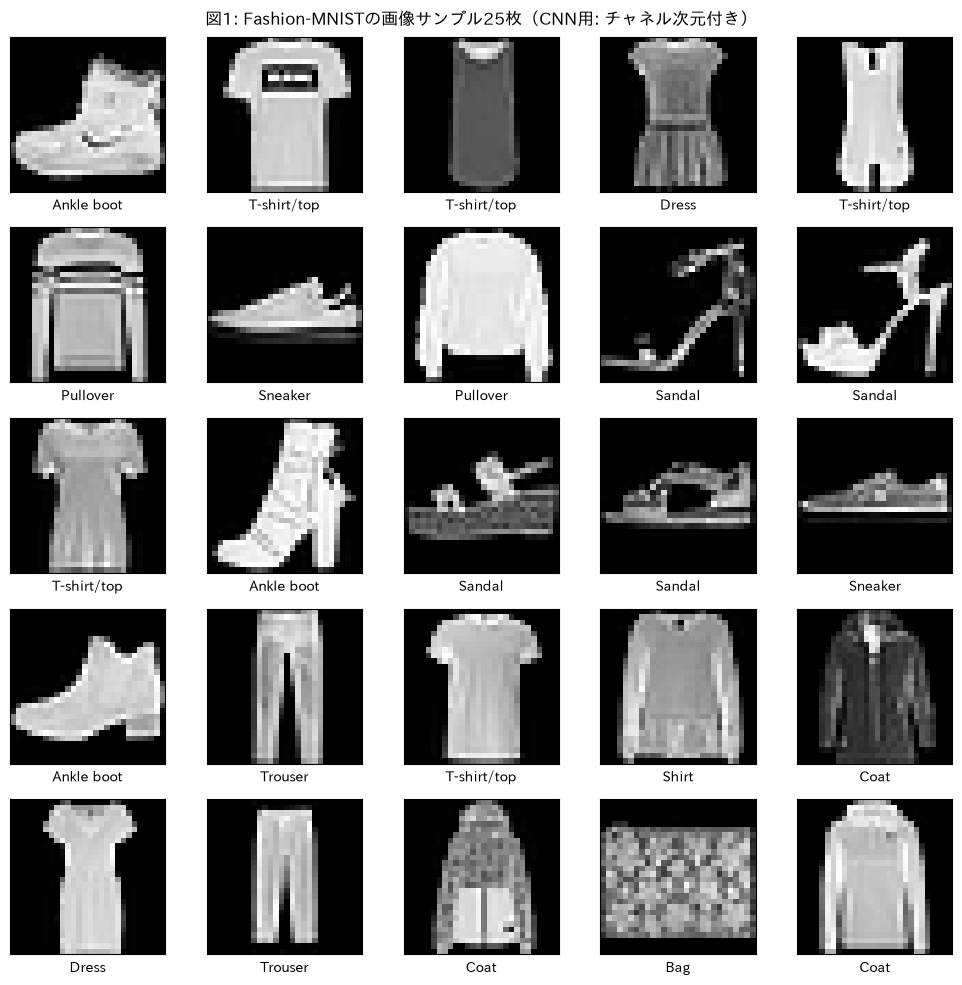

In [11]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    # imshowにはチャネル次元込みの (28, 28, 1) をそのまま渡せる
    plt.imshow(train_images[i], cmap="gray")
    plt.xlabel(class_names[train_labels_int[i]])
plt.suptitle("図1: Fashion-MNISTの画像サンプル25枚（CNN用: チャネル次元付き）")
plt.tight_layout()
plt.show()

In [4]:
print("画像の形状（1枚あたり）:", train_images.shape[1:])
print("MLP編では (28, 28) だったが、CNN編では末尾にチャネル次元(28, 28, 1)が付いている")

画像の形状（1枚あたり）: (28, 28, 1)
MLP編では (28, 28) だったが、CNN編では末尾にチャネル次元(28, 28, 1)が付いている


## 2. モデルの構築

### ステップ1: 畳み込み層（Conv2D）とは何か

`Dense`層は「すべての入力とすべての出力を結ぶ」層でした。画像に対してこれを行うと、画素の位置関係（隣同士のピクセルが似た値を持ちやすい、という画像特有の構造）を無視してしまい、パラメータ数も膨大になります。

`Conv2D`層は、画像の一部分（例えば3×3ピクセル）だけを見る小さな重み（フィルタ、カーネルとも呼ぶ）を、画像全体にずらしながら適用する層です。同じフィルタを画像全体で使い回すため、パラメータ数を抑えつつ「エッジ」「模様」のような局所的な特徴を検出できます。

`MaxPooling2D`層は、画像を縮小しながら「その領域の最大値」だけを残す層です。これにより計算量が減り、多少の位置ズレに対して頑健になります。

**このモデルの構成は、LeCunら (1998) が提案した歴史的な畳み込みネットワーク「LeNet-5」（手書き数字認識のために設計された）を参考にした、畳み込み層2つ＋全結合層2つの簡略構成です**（LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324）。原典のLeNet-5は`tanh`活性化・平均プーリングなど本ノートブックとは異なる設計上の選択をしていますが、「畳み込み→プーリング」を繰り返して特徴を抽出し、最後に全結合層で分類する、という基本構造は共通しています。

In [12]:
from tensorflow import keras
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation

model = keras.Sequential()

### ステップ2: 層を1つずつ積み、そのつど`summary()`で確認する

In [13]:
model.add(keras.Input(shape=(28, 28, 1)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same"))
model.add(Activation("relu"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640 (2.50 KB)

 Trainable params: 640 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

**コラム: `keras.Input`を最初の行に置く理由**

Kerasの公式ガイドは「あらかじめ入力形状がわかっているなら、`keras.Input(shape=...)`を先頭に置いて明示するのが推奨」としています。以前は`Conv2D(..., input_shape=(28, 28, 1))`のように後続の層へ`input_shape`を渡すだけでも動作しましたが、この書き方だと後で`model.input`（AE編で使うテクニック）にアクセスしようとしたときに`AttributeError: ... has never been called and thus has no defined input`というエラーになる事例が確認されています。本シリーズでは常に`keras.Input`を明示する書き方に統一しています。

`Conv2D(filters=64, kernel_size=(3, 3), padding="same")`は、3×3のフィルタを64種類用意し、それぞれで画像全体を走査する層です。`padding="same"`は、出力の高さ・幅が入力と同じ28×28になるよう、画像の周囲を0で埋める（パディングする）設定です。パラメータ数は `(3 × 3 × 1入力チャネル + 1バイアス) × 64フィルタ = 640` です。

In [14]:
model.add(MaxPooling2D(pool_size=(2, 2)))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640 (2.50 KB)

 Trainable params: 640 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

`MaxPooling2D(pool_size=(2, 2))`は、2×2の領域ごとに最大値を1つだけ残すので、高さ・幅がそれぞれ半分（28→14）になります。プーリング層に学習可能なパラメータはありません。

In [15]:
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,104 (74.62 KB)

 Trainable params: 19,104 (74.62 KB)

 Non-trainable params: 0 (0.00 B)

2つ目の畳み込みブロックです。1つ目のブロックの出力（14×14×64）を入力として受け取り、32種類のフィルタを適用したあと、再びプーリングで14→7へ縮小します。

In [16]:
model.add(Flatten())
model.add(Dense(units=128, activation="relu"))
model.add(Dense(units=64, activation="relu"))
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,842 (893.91 KB)

 Trainable params: 228,842 (893.91 KB)

 Non-trainable params: 0 (0.00 B)

最後は`Flatten`で7×7×32=1,568個の値を1次元に潰し、MLP編と同じ`Dense(128) → Dense(64) → Dense(10, softmax)`で分類します。「畳み込み層で特徴を抽出し、全結合層で分類する」という、CNNの典型的な構成です。

**コラム: `Conv2D` + `Activation`と`Conv2D(activation=...)`の違い**

本ノートブックでは`Conv2D(...)`のあとに`Activation("relu")`を別の層として追加していますが、`Conv2D(filters=64, kernel_size=(3, 3), activation="relu")`のように引数として活性化関数を指定することもできます。動作は同じですが、`Activation`を独立させておくと、活性化前の値（バッチ正規化などを挟みたい場合に必要になることがある）にアクセスしやすくなります。目的に応じて使い分けてください。

### ステップ3: モデルをコンパイルする

In [17]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

MLP編では`optimizer="adam"`でしたが、本ノートブックでは元の教材の設定を踏襲して`"rmsprop"`を使っています。どちらも「勾配の情報を使って学習率を自動調整する」系統の最適化アルゴリズムで、実務では`"adam"`が既定選択として使われることが多いものの、`"rmsprop"`も画像系のタスクでよく使われます。余力があれば演習問題でどちらが良い結果になるか比較してみてください。

## 3. 学習

MLP編と同じくテストデータを`validation_data`として使う簡略構成です（詳しくはMLP編1節ステップ2のコラムを参照）。畳み込み層はMLPの全結合層より演算量が多いため、1エポックあたりの実行時間はMLPより長くなります。

In [18]:
%%time
history = model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=128,
    validation_data=(test_images, test_labels),
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8018 - loss: 0.5374 - val_accuracy: 0.8631 - val_loss: 0.3873
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8841 - loss: 0.3180 - val_accuracy: 0.8900 - val_loss: 0.3139
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9036 - loss: 0.2620 - val_accuracy: 0.8945 - val_loss: 0.2953
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9165 - loss: 0.2269 - val_accuracy: 0.9021 - val_loss: 0.2811
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9264 - loss: 0.2000 - val_accuracy: 0.9067 - val_loss: 0.2712
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9344 - loss: 0.1784 - val_accuracy: 0.9051 - val_loss: 0.2715
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9426 - loss: 0.1582 - val_accuracy: 0.9079 - val_loss: 0.2729
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9486 - loss: 0.1402 - 

## 4. 評価とまとめ

### ステップ1: 損失関数の値と正解率の最終値を確認する

In [19]:
train_loss_cnn_seq, train_acc_cnn_seq = model.evaluate(train_images, train_labels, verbose=0)
test_loss_cnn_seq, test_acc_cnn_seq = model.evaluate(test_images, test_labels, verbose=0)

print("訓練データの損失関数の値:", train_loss_cnn_seq)
print("テストデータの損失関数の値:", test_loss_cnn_seq)
print("訓練データの分類精度:", train_acc_cnn_seq)
print("テストデータの分類精度:", test_acc_cnn_seq)

訓練データの損失関数の値: 0.12911951541900635
テストデータの損失関数の値: 0.7823398113250732
訓練データの分類精度: 0.9656333327293396
テストデータの分類精度: 0.9003000259399414


### ステップ2: 学習曲線を可視化する（図2・図3）

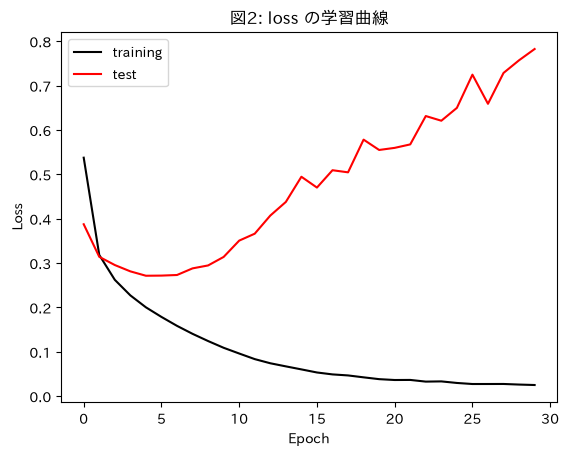

In [20]:
viz_utils.plot_metric_curve(history, metric="loss", fig_num=2, output_dir=OUTPUT_DIR)

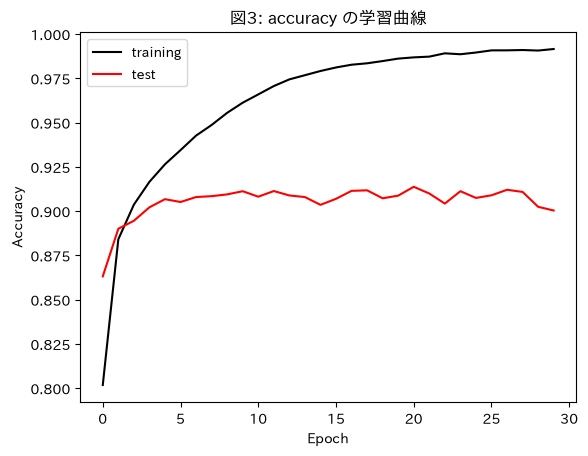

In [21]:
viz_utils.plot_metric_curve(history, metric="accuracy", fig_num=3, output_dir=OUTPUT_DIR)

### ステップ3: 混同行列を確認する（図4）

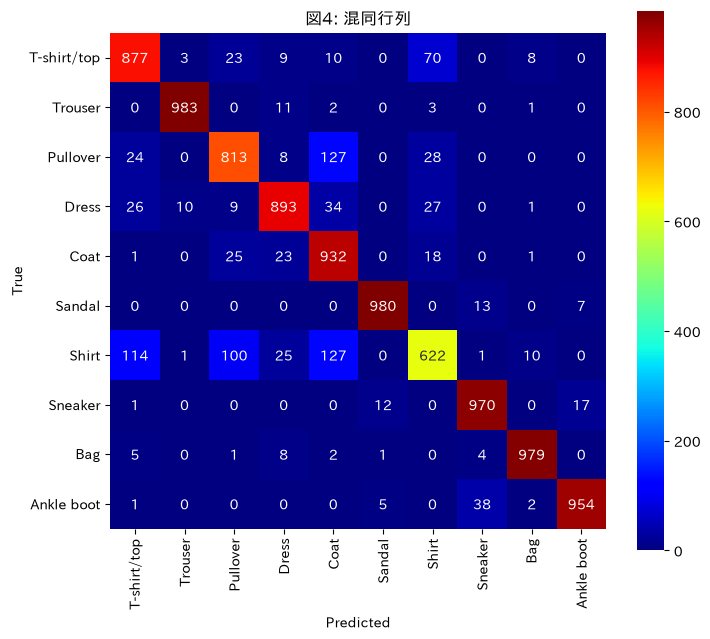

In [22]:
test_pred_proba_cnn_seq = model.predict(test_images, verbose=0)
test_pred_class_cnn_seq = np.argmax(test_pred_proba_cnn_seq, axis=1)

cm_cnn_seq = viz_utils.plot_confusion_matrix(
    test_labels_int, test_pred_class_cnn_seq,
    class_names=class_names, fig_num=4, output_dir=OUTPUT_DIR,
)

### ステップ4: 学習済みモデルを保存する

In [23]:
model_path = OUTPUT_DIR / "cnn_seq_trained.keras"
history_path = data_utils.save_history(OUTPUT_DIR, "history_cnn_seq.npz", history)
model.save(model_path)
print("保存しました:", model_path, "/", history_path)

保存しました: c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\output\cnn_seq_trained.keras / c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\code\output\history_cnn_seq.npz


このファイルは、この後の`2_Keras_CNN_Functional-API.ipynb`が「Sequential版とFunctional版で同じ構造のモデルができているか」を確認するために読み込みます。

### ステップ5: MLPとの比較表・比較図を作る（図5）

In [24]:
import csv

COMPARISON_DIR = BASE_DIR.parent / "comparison_output"
COMPARISON_DIR.mkdir(exist_ok=True)
comparison_path = COMPARISON_DIR / "classification_comparison.csv"

row = {
    "model": "CNN",
    "api_style": "Sequential",
    "dataset": "Fashion-MNIST",
    "test_loss": test_loss_cnn_seq,
    "test_acc": test_acc_cnn_seq,
}
file_exists = comparison_path.exists()
with open(comparison_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(row.keys()))
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f"記録先: {comparison_path}")

記録先: c:\Users\japan\Dropbox\ARIM\Code-brushup_2\2024_data\comparison_output\classification_comparison.csv


In [25]:
import pandas as pd

comparison_df = pd.read_csv(comparison_path)
comparison_df

,model,api_style,dataset,test_loss,test_acc
0,MLP,Sequential,Fashion-MNIST,0.455382,0.8773
1,MLP,Sequential,Fashion-MNIST,0.455382,0.8773
2,CNN,Sequential,Fashion-MNIST,0.782340,0.9003


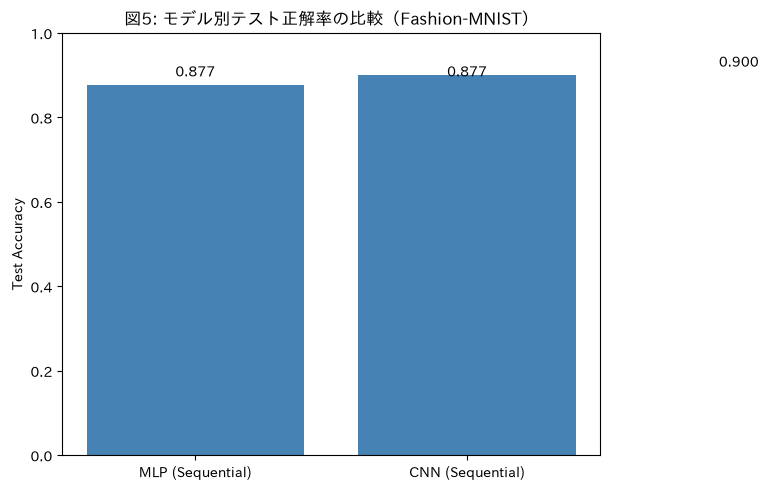

In [26]:
plt.figure(figsize=(8, 5))
labels_for_bar = comparison_df["model"] + " (" + comparison_df["api_style"] + ")"
plt.bar(labels_for_bar, comparison_df["test_acc"], color="steelblue")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.title("図5: モデル別テスト正解率の比較（Fashion-MNIST）")
for i, acc in enumerate(comparison_df["test_acc"]):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig5_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

`classification_comparison.csv`に記録した`MLP`の結果と本ノートブックの`CNN (Sequential)`の結果を並べると、一般に画像の位置関係を利用できるCNNの方がMLPより高い正解率になります（実際の数値は実行環境によって多少前後します）。「なぜCNNの方が有利なのか」は、2節ステップ1で説明した「畳み込みによる局所特徴の抽出」が理由です。

## まとめ

- Fashion-MNISTに対して、`Conv2D`＋`MaxPooling2D`を2ブロック積んだCNN（LeNet-5にならった簡略構成）をSequential APIで構築した
- チャネル次元`(28, 28, 1)`を明示的に追加する必要がある点が、MLP編との前処理上の主な違いだった
- MLPとの比較表・比較図を作成し、CNNの方が高い正解率を達成する傾向を確認した

## 本ノートブックで扱っていないこと（今後の課題）

- データ拡張（回転・反転などでデータを水増しする）による性能向上
- バッチ正規化（`BatchNormalization`）やドロップアウト（`Dropout`）による過学習対策
- より深い・現代的なアーキテクチャ（ResNetなど）との比較。次の`2_Keras_CNN_Functional-API.ipynb`では、同じモデルをFunctional APIで書き直し、書き方の違いを比較する

## 演習問題

1. `optimizer`を`"rmsprop"`から`"adam"`に変更して学習し直し、最終的な正解率がどう変わるか比較しなさい。
2. `Conv2D`の`filters`を64→32、32→16のように半分に減らすと、パラメータ数と正解率はどう変化するか確認しなさい。
3. 混同行列（図4）をMLP編の混同行列と見比べ、CNNによって改善されたクラスの組み合わせを2つ挙げなさい。
4. `MaxPooling2D`を1つ減らした（プーリングを1回だけにした）モデルを作り、`Flatten`直前の出力形状がどう変わるか、`model.summary()`で確認しなさい。